## 1. Imports, image loading and maze rectification


In [1]:
from __future__ import annotations

import heapq
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import cv2
import numpy as np


DIRECTIONS = ("N", "E", "S", "W")
DELTAS = ((-1, 0), (0, 1), (1, 0), (0, -1))
PROCESS_CELL_PX = 100
DISPLAY_CELL_PX = 78
PANEL_WIDTH = 390


def read_image(path: Path) -> np.ndarray:
    data = np.fromfile(str(path), dtype=np.uint8)
    image = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f"Could not read image: {path}")
    return image


def write_image(path: Path, image: np.ndarray) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    suffix = path.suffix or ".png"
    ok, encoded = cv2.imencode(suffix, image)
    if not ok:
        raise ValueError(f"Could not encode image: {path}")
    encoded.tofile(str(path))


def order_quad(points: np.ndarray) -> np.ndarray:
    points = np.asarray(points, dtype=np.float32)
    sums = points.sum(axis=1)
    differences = np.diff(points, axis=1).ravel()
    return np.array(
        [
            points[np.argmin(sums)],
            points[np.argmin(differences)],
            points[np.argmax(sums)],
            points[np.argmax(differences)],
        ],
        dtype=np.float32,
    )


def resize_for_detection(image: np.ndarray, maximum: int = 1800) -> np.ndarray:
    height, width = image.shape[:2]
    scale = min(1.0, maximum / max(height, width))
    if scale == 1.0:
        return image.copy()
    return cv2.resize(image, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)


def largest_dense_cluster(points: np.ndarray, radius: float) -> np.ndarray:
    if len(points) == 0:
        return points

    unused = set(range(len(points)))
    clusters = []
    radius_squared = radius * radius
    while unused:
        seed = unused.pop()
        cluster = [seed]
        queue = [seed]
        while queue:
            current = queue.pop()
            if not unused:
                continue
            candidates = list(unused)
            delta = points[candidates] - points[current]
            nearby = [
                candidates[index]
                for index, value in enumerate(delta)
                if float(value @ value) <= radius_squared
            ]
            for index in nearby:
                unused.remove(index)
                cluster.append(index)
                queue.append(index)
        clusters.append(cluster)
    return points[max(clusters, key=len)]


def cyan_structure_mask(image: np.ndarray) -> np.ndarray:
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, (86, 55, 28), (108, 255, 255))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    return cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)


def detect_coarse_maze_quad(image: np.ndarray) -> np.ndarray:
    cyan = cyan_structure_mask(image)
    count, _, stats, centroids = cv2.connectedComponentsWithStats(cyan)
    image_area = image.shape[0] * image.shape[1]
    minimum_area = max(4, int(image_area * 0.000002))
    maximum_area = max(300, int(image_area * 0.004))
    points = np.array(
        [
            centroids[index]
            for index in range(1, count)
            if minimum_area <= stats[index, cv2.CC_STAT_AREA] <= maximum_area
        ],
        dtype=np.float32,
    )

    if len(points) >= 20:
        cluster = largest_dense_cluster(points, 0.13 * min(image.shape[:2]))
        if len(cluster) >= 15:
            rectangle = cv2.minAreaRect(cluster.astype(np.float32))
            return order_quad(cv2.boxPoints(rectangle))

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (7, 7), 0), 45, 130)
    edges = cv2.morphologyEx(
        edges,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_RECT, (11, 11)),
        iterations=2,
    )
    contours = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)[-2]
    candidates = []
    for contour in contours:
        area = cv2.contourArea(contour)
        if area < image_area * 0.12:
            continue
        hull = cv2.convexHull(contour)
        perimeter = cv2.arcLength(hull, True)
        for epsilon in (0.015, 0.025, 0.04):
            polygon = cv2.approxPolyDP(hull, epsilon * perimeter, True)
            if len(polygon) == 4 and cv2.isContourConvex(polygon):
                candidates.append((area, order_quad(polygon[:, 0, :])))
                break
    if candidates:
        return max(candidates, key=lambda item: item[0])[1]
    raise RuntimeError("Maze frame was not detected. Retake the photo from above.")


def warp_quad(image: np.ndarray, quad: np.ndarray, width: int, height: int) -> np.ndarray:
    destination = np.array(
        [[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]],
        dtype=np.float32,
    )
    matrix = cv2.getPerspectiveTransform(order_quad(quad), destination)
    return cv2.warpPerspective(image, matrix, (width, height))


def fit_regular_lattice(projection: np.ndarray, line_count: int) -> tuple[float, float]:
    projection = projection.astype(np.float32).reshape(-1)
    projection = cv2.GaussianBlur(projection.reshape(1, -1), (0, 0), 4).ravel()
    projection /= float(projection.max() + 1e-6)
    length = len(projection)
    ideal_step = length / max(1, line_count - 1)
    best_score = -math.inf
    best_origin = 0.0
    best_step = ideal_step

    for step in np.arange(ideal_step * 0.74, ideal_step * 1.10, 0.5):
        maximum_origin = length - 1 - step * (line_count - 1)
        if maximum_origin < 0:
            continue
        for origin in np.arange(0.0, maximum_origin + 0.25, 0.5):
            positions = origin + step * np.arange(line_count)
            score = 0.0
            for position in positions:
                centre = int(round(position))
                low = max(0, centre - 4)
                high = min(length, centre + 5)
                score += float(projection[low:high].max())
            span_bonus = 0.08 * step * (line_count - 1) / length
            score += span_bonus
            if score > best_score:
                best_score = score
                best_origin = float(origin)
                best_step = float(step)
    return best_origin, best_step


def rectify_maze(image: np.ndarray, rows: int, columns: int) -> tuple[np.ndarray, np.ndarray]:
    detection_image = resize_for_detection(image)
    coarse_quad = detect_coarse_maze_quad(detection_image)
    coarse = warp_quad(detection_image, coarse_quad, 1000, 1000)
    cyan = cyan_structure_mask(coarse)

    x_origin, x_step = fit_regular_lattice(cyan.sum(axis=0), columns + 1)
    y_origin, y_step = fit_regular_lattice(cyan.sum(axis=1), rows + 1)
    x_end = x_origin + columns * x_step
    y_end = y_origin + rows * y_step

    grid_quad = np.array(
        [[x_origin, y_origin], [x_end, y_origin], [x_end, y_end], [x_origin, y_end]],
        dtype=np.float32,
    )
    rectified = warp_quad(
        coarse,
        grid_quad,
        columns * PROCESS_CELL_PX,
        rows * PROCESS_CELL_PX,
    )
    return rectified, cyan


def _odd_size(value: float, minimum: int = 3) -> int:
    size = max(minimum, int(round(value)))
    return size if size % 2 else size + 1


def _wall_component_score(
    mask: np.ndarray,
    vertical: bool,
    segment: int,
    grid_line: int,
    rows: int,
    columns: int,
) -> float:
    """Measure wall coverage inside one grid edge, allowing post-sized gaps."""
    height, width = mask.shape
    cell_x = width / columns
    cell_y = height / rows
    if vertical:
        y_low = int(round((segment + 0.08) * cell_y))
        y_high = int(round((segment + 0.92) * cell_y))
        x_low = max(0, int(round(grid_line * cell_x - cell_x * 0.40)))
        x_high = min(width, int(round(grid_line * cell_x + cell_x * 0.40)) + 1)
        along_cell = cell_y
        across_cell = cell_x
        target = grid_line * cell_x
    else:
        x_low = int(round((segment + 0.08) * cell_x))
        x_high = int(round((segment + 0.92) * cell_x))
        y_low = max(0, int(round(grid_line * cell_y - cell_y * 0.40)))
        y_high = min(height, int(round(grid_line * cell_y + cell_y * 0.40)) + 1)
        along_cell = cell_x
        across_cell = cell_y
        target = grid_line * cell_y

    crop = mask[y_low:y_high, x_low:x_high]
    count, labels, stats, _ = cv2.connectedComponentsWithStats(crop)
    projection_length = crop.shape[0] if vertical else crop.shape[1]
    projection = np.zeros(projection_length, dtype=bool)
    for index in range(1, count):
        x, y, component_width, component_height, area = stats[index]
        length = component_height if vertical else component_width
        thickness = component_width if vertical else component_height
        if area < cell_x * cell_y * 0.002:
            continue
        if length < along_cell * 0.65 and length < thickness * 1.35:
            continue
        axis_edges = (
            (x_low + x, x_low + x + component_width - 1)
            if vertical
            else (y_low + y, y_low + y + component_height - 1)
        )
        if min(abs(value - target) for value in axis_edges) > across_cell * 0.30:
            continue
        component = labels == index
        projection |= np.any(component, axis=1 if vertical else 0)

    occupied = np.flatnonzero(projection)
    if occupied.size == 0:
        return 0.0
    coverage = occupied.size / along_cell
    span = (occupied[-1] - occupied[0] + 1) / along_cell
    if coverage >= 0.65 and span >= 0.65:
        return 1.0
    if coverage >= 0.45 and span >= 0.45:
        return 0.70
    return 0.0


def _promote_parallel(
    scores: np.ndarray,
    candidates: np.ndarray,
    axis: int,
    candidate_threshold: float,
) -> None:
    """Promote a candidate beside a confirmed parallel wall."""
    strong = scores >= 0.85
    neighbour = np.zeros_like(strong)
    if axis == 1:
        neighbour[:, 1:] |= strong[:, :-1]
        neighbour[:, :-1] |= strong[:, 1:]
    else:
        neighbour[1:] |= strong[:-1]
        neighbour[:-1] |= strong[1:]
    scores[(candidates >= candidate_threshold) & ~strong & neighbour] = 1.0


def _promote_relaxed_vertical_corners(
    vertical_scores: np.ndarray,
    relaxed_vertical_scores: np.ndarray,
    horizontal_scores: np.ndarray,
) -> None:
    """Confirm a light vertical panel joined to horizontal walls at both ends."""
    rows, vertical_lines = vertical_scores.shape
    columns = vertical_lines - 1
    for row in range(rows):
        for column in range(vertical_lines):
            if (
                vertical_scores[row, column] >= 0.85
                or relaxed_vertical_scores[row, column] < 0.85
            ):
                continue
            top_corner = (
                (column > 0 and horizontal_scores[row, column - 1] >= 0.85)
                or (column < columns and horizontal_scores[row, column] >= 0.85)
            )
            bottom_corner = (
                (column > 0 and horizontal_scores[row + 1, column - 1] >= 0.85)
                or (
                    column < columns
                    and horizontal_scores[row + 1, column] >= 0.85
                )
            )
            if top_corner and bottom_corner:
                vertical_scores[row, column] = 1.0


def _line_contrast(
    gray: np.ndarray,
    line: tuple[int, int, int, int],
    horizontal: bool,
    otsu_level: float,
    cell: float,
) -> float:
    x1, y1, x2, y2 = line
    line_mask = np.zeros(gray.shape, dtype=np.uint8)
    cv2.line(
        line_mask,
        (x1, y1),
        (x2, y2),
        255,
        max(3, int(round(cell * 0.05))),
    )
    line_value = float(np.percentile(gray[line_mask > 0], 25))
    padding = max(8, int(round(cell * 0.14)))
    x_low = max(0, min(x1, x2) - padding)
    x_high = min(gray.shape[1], max(x1, x2) + padding + 1)
    y_low = max(0, min(y1, y2) - padding)
    y_high = min(gray.shape[0], max(y1, y2) + padding + 1)
    background = float(np.percentile(gray[y_low:y_high, x_low:x_high], 75))
    contrast = background - line_value
    value_limit = min(148.0, otsu_level + 10.0)
    strict_limit = min(108.0, otsu_level * 0.76)

    side_values = []
    side_offset = max(8, int(round(cell * 0.12)))
    for offset in (-side_offset, side_offset):
        side_mask = np.zeros(gray.shape, dtype=np.uint8)
        shift_x, shift_y = (0, offset) if horizontal else (offset, 0)
        cv2.line(
            side_mask,
            (x1 + shift_x, y1 + shift_y),
            (x2 + shift_x, y2 + shift_y),
            255,
            max(3, int(round(cell * 0.05))),
        )
        side_pixels = gray[side_mask > 0]
        side_values.append(
            float(np.percentile(side_pixels, 60)) if side_pixels.size else 255.0
        )
    if min(side_values) < strict_limit + 12.0:
        return 0.0

    # Floor seams are long but pale. A thin wall must either be absolutely
    # dark or have a clear local contrast against the floor on both sides.
    if line_value >= value_limit or (
        line_value >= strict_limit and contrast < otsu_level * 0.23
    ):
        return 0.0
    darkness = (value_limit - line_value) / max(30.0, otsu_level * 0.40)
    contrast_score = contrast / max(35.0, otsu_level * 0.43)
    return float(np.clip(max(darkness, contrast_score), 0.0, 1.0))


def _add_thin_wall_lines(
    edges: np.ndarray,
    gray: np.ndarray,
    horizontal_scores: np.ndarray,
    vertical_scores: np.ndarray,
    rows: int,
    columns: int,
    otsu_level: float,
) -> None:
    """Recover dark walls seen nearly edge-on."""
    height, width = gray.shape
    cell_x, cell_y = width / columns, height / rows
    cell = min(cell_x, cell_y)
    lines = cv2.HoughLinesP(
        edges, 1, np.pi / 180,
        threshold=max(18, int(round(cell * 0.25))),
        minLineLength=max(32, int(round(cell * 0.42))),
        maxLineGap=max(7, int(round(cell * 0.10))),
    )
    if lines is None:
        return

    horizontal_support = np.zeros_like(horizontal_scores)
    vertical_support = np.zeros_like(vertical_scores)
    for x1, y1, x2, y2 in lines[:, 0]:
        dx, dy = float(x2 - x1), float(y2 - y1)
        horizontal = abs(dx) >= cell_x * 0.42 and abs(dy) <= max(5.0, abs(dx) * 0.12)
        vertical = abs(dy) >= cell_y * 0.42 and abs(dx) <= max(5.0, abs(dy) * 0.12)
        if not horizontal and not vertical:
            continue
        confidence = _line_contrast(
            gray, (int(x1), int(y1), int(x2), int(y2)),
            horizontal, otsu_level, cell,
        )
        if confidence < 0.55:
            continue

        if horizontal:
            axis, step, along = (y1 + y2) * 0.5, cell_y, cell_x
            line_count, segment_count = rows, columns
            start, end = sorted((x1, x2))
            support = horizontal_support
        else:
            axis, step, along = (x1 + x2) * 0.5, cell_x, cell_y
            line_count, segment_count = columns, rows
            start, end = sorted((y1, y2))
            support = vertical_support

        grid_line = int(round(axis / step))
        if abs(axis - grid_line * step) > step * 0.18 or not 0 <= grid_line <= line_count:
            continue
        for segment in range(segment_count):
            overlap = max(0.0, min(end, (segment + 1) * along) - max(start, segment * along))
            if overlap < along * 0.38:
                continue
            index = (grid_line, segment) if horizontal else (segment, grid_line)
            support[index] += overlap * confidence / (along * 0.55)

    horizontal_thin = np.clip(horizontal_support, 0.0, 1.0)
    vertical_thin = np.clip(vertical_support, 0.0, 1.0)
    for boundary_row in (0, rows - 1):
        vertical_thin[boundary_row][vertical_thin[boundary_row] >= 0.65] = 1.0
    np.maximum(horizontal_scores, horizontal_thin, out=horizontal_scores)
    np.maximum(vertical_scores, vertical_thin, out=vertical_scores)


def _add_endpoint_horizontal_walls(
    edges: np.ndarray,
    gray: np.ndarray,
    cyan: np.ndarray,
    scores: np.ndarray,
    rows: int,
    columns: int,
    otsu_level: float,
) -> None:
    """Recover a thin horizontal wall between two cyan endpoints."""
    height, width = gray.shape
    cell_x, cell_y = width / columns, height / rows
    cell = min(cell_x, cell_y)
    raw_edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 35, 110)
    radius = max(12, int(round(cell * 0.28)))

    def cyan_pixels(x: int, y: int) -> int:
        return int(np.count_nonzero(cyan[
            max(0, y - radius):min(height, y + radius + 1),
            max(0, x - radius):min(width, x + radius + 1),
        ]))

    def hough(edge_map: np.ndarray, y0: int, y1: int, x0: int, x1: int):
        return cv2.HoughLinesP(
            edge_map[y0:y1, x0:x1], 1, np.pi / 180,
            threshold=max(10, int(round(cell * 0.12))),
            minLineLength=max(24, int(round(cell_x * 0.30))),
            maxLineGap=max(10, int(round(cell_x * 0.18))),
        )

    def aligned(line, x0: int, y0: int, target_y: int):
        x1, y1, x2, y2 = line
        length = abs(float(x2 - x1))
        if length < cell_x * 0.50 or abs(float(y2 - y1)) > max(6.0, length * 0.12):
            return None
        absolute = (int(x1 + x0), int(y1 + y0), int(x2 + x0), int(y2 + y0))
        if abs((absolute[1] + absolute[3]) * 0.5 - target_y) > cell_y * 0.18:
            return None
        return length, absolute

    for row in range(1, rows):
        y = int(round(row * cell_y))
        y0 = max(0, int(round(y - cell_y * 0.24)))
        y1 = min(height, int(round(y + cell_y * 0.24)) + 1)
        for column in range(columns):
            if scores[row, column] >= 0.85:
                continue
            x0, x1 = int(round(column * cell_x)), int(round((column + 1) * cell_x))
            if min(cyan_pixels(x0, y), cyan_pixels(x1, y)) < cell * cell * 0.009:
                continue

            lines = hough(edges, y0, y1, x0, x1)
            for line in [] if lines is None else lines[:, 0]:
                candidate = aligned(line, x0, y0, y)
                if candidate and _line_contrast(gray, candidate[1], True, otsu_level, cell) >= 0.55:
                    scores[row, column] = 1.0
                    break
            if scores[row, column] >= 0.85 or column != 0 or row >= rows - 2:
                continue

            lines = hough(raw_edges, y0, y1, x0, x1)
            for line in [] if lines is None else lines[:, 0]:
                candidate = aligned(line, x0, y0, y)
                if candidate and candidate[0] >= cell_x * 0.70 and max(line[0], line[2]) >= cell_x * 0.90:
                    scores[row, column] = 1.0
                    break


def _directional_wall_mask(
    blurred: np.ndarray,
    cyan_guard: np.ndarray,
    limit: int,
    vertical: bool,
    cell: float,
) -> np.ndarray:
    mask = cv2.inRange(blurred, 0, limit)
    mask[cyan_guard > 0] = 0
    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)),
    )
    length = _odd_size(cell * 0.29)
    kernel = (3, length) if vertical else (length, 3)
    return cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_RECT, kernel),
    )


def _component_score_grid(
    mask: np.ndarray,
    vertical: bool,
    rows: int,
    columns: int,
) -> np.ndarray:
    shape = (rows, columns + 1) if vertical else (rows + 1, columns)
    scores = np.zeros(shape, dtype=np.float32)
    for row in range(shape[0]):
        for column in range(shape[1]):
            segment, line = (row, column) if vertical else (column, row)
            scores[row, column] = _wall_component_score(
                mask,
                vertical,
                segment,
                line,
                rows,
                columns,
            )
    return scores


def _draw_score_walls(
    preview: np.ndarray,
    scores: np.ndarray,
    vertical: bool,
    cell_x: float,
    cell_y: float,
) -> None:
    for row, column in np.argwhere(scores >= 0.85):
        if vertical:
            if column in (0, scores.shape[1] - 1):
                continue
            x = int(round(column * cell_x))
            points = ((x, int(round(row * cell_y))), (x, int(round((row + 1) * cell_y))))
        else:
            if row in (0, scores.shape[0] - 1):
                continue
            y = int(round(row * cell_y))
            points = ((int(round(column * cell_x)), y), (int(round((column + 1) * cell_x)), y))
        cv2.line(preview, *points, 255, 3)


def preprocess_wall_evidence(
    image: np.ndarray,
    rows: int,
    columns: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Detect broad, thin, and lightly shaded grid walls."""
    height, width = image.shape[:2]
    cell_x, cell_y = width / columns, height / rows
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    otsu_level, _ = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU,
    )
    cyan = cyan_structure_mask(image)
    cyan_guard = cv2.dilate(
        cyan,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)),
    )

    horizontal_mask = _directional_wall_mask(
        blurred,
        cyan_guard,
        min(108, int(round(otsu_level * 0.76))),
        False,
        cell_x,
    )
    vertical_mask = _directional_wall_mask(
        blurred,
        cyan_guard,
        min(108, int(round(otsu_level * 0.76))),
        True,
        cell_y,
    )
    relaxed_vertical_mask = _directional_wall_mask(
        blurred,
        cyan_guard,
        min(160, int(round(otsu_level * 1.08))),
        True,
        cell_y,
    )

    horizontal_scores = _component_score_grid(horizontal_mask, False, rows, columns)
    vertical_scores = _component_score_grid(vertical_mask, True, rows, columns)
    relaxed_vertical_scores = _component_score_grid(
        relaxed_vertical_mask,
        True,
        rows,
        columns,
    )

    enhanced = cv2.createCLAHE(clipLimit=1.8, tileGridSize=(8, 8)).apply(gray)
    edges = cv2.Canny(
        cv2.GaussianBlur(enhanced, (3, 3), 0),
        max(35, int(round(otsu_level * 0.36))),
        max(100, int(round(otsu_level * 1.02))),
        L2gradient=True,
    )
    edges[
        cv2.dilate(
            cyan,
            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)),
        )
        > 0
    ] = 0
    _add_thin_wall_lines(
        edges,
        gray,
        horizontal_scores,
        vertical_scores,
        rows,
        columns,
        float(otsu_level),
    )
    _add_endpoint_horizontal_walls(
        edges,
        gray,
        cyan,
        horizontal_scores,
        rows,
        columns,
        float(otsu_level),
    )

    _promote_parallel(horizontal_scores, horizontal_scores, axis=1, candidate_threshold=0.65)
    _promote_parallel(vertical_scores, vertical_scores, axis=0, candidate_threshold=0.65)
    _promote_parallel(vertical_scores, relaxed_vertical_scores, axis=0, candidate_threshold=0.85)
    _promote_relaxed_vertical_corners(
        vertical_scores,
        relaxed_vertical_scores,
        horizontal_scores,
    )

    preview = cv2.bitwise_or(horizontal_mask, vertical_mask)
    _draw_score_walls(preview, horizontal_scores, False, cell_x, cell_y)
    _draw_score_walls(preview, vertical_scores, True, cell_x, cell_y)
    return preview, horizontal_scores, vertical_scores


## 2. Wall recognition and maze representation


In [2]:
def detect_blocked_cells(image: np.ndarray, rows: int, columns: int) -> np.ndarray:
    """Detect the cells cut off by the diagonal outer frame."""
    blocked = np.zeros((rows, columns), dtype=bool)
    if rows < 3 or columns < 3:
        return blocked

    height, width = image.shape[:2]
    cell = min(width / columns, height / rows)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 35, 110)
    lines = cv2.HoughLinesP(
        edges,
        1,
        np.pi / 180,
        threshold=max(24, int(cell * 0.30)),
        minLineLength=max(35, int(cell * 0.52)),
        maxLineGap=max(12, int(cell * 0.25)),
    )

    evidence = np.zeros(4, dtype=np.float32)
    if lines is not None:
        for x1, y1, x2, y2 in lines[:, 0]:
            dx = float(x2 - x1)
            dy = float(y2 - y1)
            length = math.hypot(dx, dy)
            angle = abs(math.degrees(math.atan2(dy, dx))) % 180.0
            if min(abs(angle - 45.0), abs(angle - 135.0)) > 24.0:
                continue

            middle_x = (x1 + x2) * 0.5
            middle_y = (y1 + y2) * 0.5
            distances = np.array(
                [
                    middle_x + middle_y,
                    width - middle_x + middle_y,
                    middle_x + height - middle_y,
                    width - middle_x + height - middle_y,
                ]
            )
            corner = int(np.argmin(distances))
            if distances[corner] < cell * 2.8:
                evidence[corner] += length

    # The course board has four matching chamfers. Two clearly visible corners
    # are enough because perspective can hide part of the lower frame.
    if np.count_nonzero(evidence > cell * 0.70) >= 2:
        for row in range(2):
            for column in range(2):
                if row + column >= 2:
                    continue
                blocked[row, column] = True
                blocked[row, columns - 1 - column] = True
                blocked[rows - 1 - row, column] = True
                blocked[rows - 1 - row, columns - 1 - column] = True
    return blocked


@dataclass
class Maze:
    rows: int
    columns: int
    horizontal_walls: np.ndarray
    vertical_walls: np.ndarray
    horizontal_scores: np.ndarray
    vertical_scores: np.ndarray
    threshold: float
    blocked_cells: np.ndarray

    def can_move(self, row: int, column: int, direction: int) -> bool:
        if self.blocked_cells[row, column]:
            return False
        if direction == 0:
            blocked = self.horizontal_walls[row, column]
        elif direction == 1:
            blocked = self.vertical_walls[row, column + 1]
        elif direction == 2:
            blocked = self.horizontal_walls[row + 1, column]
        else:
            blocked = self.vertical_walls[row, column]
        if blocked:
            return False
        next_row = row + DELTAS[direction][0]
        next_column = column + DELTAS[direction][1]
        if not (0 <= next_row < self.rows and 0 <= next_column < self.columns):
            return False
        return not self.blocked_cells[next_row, next_column]


def extract_maze(image: np.ndarray, rows: int, columns: int) -> tuple[Maze, np.ndarray]:
    occupancy, horizontal_scores, vertical_scores = preprocess_wall_evidence(
        image,
        rows,
        columns,
    )
    threshold = 0.85
    horizontal_walls = horizontal_scores >= threshold
    vertical_walls = vertical_scores >= threshold
    horizontal_walls[0, :] = True
    horizontal_walls[-1, :] = True
    vertical_walls[:, 0] = True
    vertical_walls[:, -1] = True
    maze = Maze(
        rows,
        columns,
        horizontal_walls,
        vertical_walls,
        horizontal_scores,
        vertical_scores,
        threshold,
        detect_blocked_cells(image, rows, columns),
    )
    return maze, occupancy


## 3. Direction-aware shortest-path planning


In [3]:
def plan_commands(
    maze: Maze,
    start: tuple[int, int, int],
    goal: tuple[int, int, int],
) -> tuple[str, list[tuple[int, int]]]:
    if maze.blocked_cells[start[0], start[1]] or maze.blocked_cells[goal[0], goal[1]]:
        return "", []
    queue = [(0, 0, 0, start)]
    costs = {start: (0, 0)}
    previous: dict[tuple[int, int, int], tuple[tuple[int, int, int], str]] = {}
    sequence = 0

    while queue:
        forwards, turns, _, state = heapq.heappop(queue)
        if costs.get(state) != (forwards, turns):
            continue
        if state == goal:
            break
        row, column, direction = state
        transitions = [
            ("l", (row, column, (direction - 1) % 4), (forwards, turns + 1)),
            ("r", (row, column, (direction + 1) % 4), (forwards, turns + 1)),
        ]
        if maze.can_move(row, column, direction):
            delta_row, delta_column = DELTAS[direction]
            transitions.append(
                (
                    "f",
                    (row + delta_row, column + delta_column, direction),
                    (forwards + 1, turns),
                )
            )
        for command, next_state, next_cost in transitions:
            if next_cost >= costs.get(next_state, (math.inf, math.inf)):
                continue
            costs[next_state] = next_cost
            previous[next_state] = (state, command)
            sequence += 1
            heapq.heappush(queue, (*next_cost, sequence, next_state))

    if goal not in costs:
        return "", []

    commands = []
    state = goal
    while state != start:
        state, command = previous[state]
        commands.append(command)
    commands.reverse()

    row, column, direction = start
    cells = [(row, column)]
    for command in commands:
        if command == "l":
            direction = (direction - 1) % 4
        elif command == "r":
            direction = (direction + 1) % 4
        else:
            row += DELTAS[direction][0]
            column += DELTAS[direction][1]
            cells.append((row, column))
    return "".join(commands), cells


def pose_text(pose: Optional[tuple[int, int, int]]) -> str:
    if pose is None:
        return "-"
    return f"({pose[0]},{pose[1]},{DIRECTIONS[pose[2]]})"


def draw_arrow(image: np.ndarray, pose: tuple[int, int, int], color: tuple[int, int, int]) -> None:
    row, column, direction = pose
    cell = DISPLAY_CELL_PX
    centre = (column * cell + cell // 2, row * cell + cell // 2)
    delta_row, delta_column = DELTAS[direction]
    end = (
        int(centre[0] + delta_column * cell * 0.32),
        int(centre[1] + delta_row * cell * 0.32),
    )
    cv2.arrowedLine(image, centre, end, color, 5, cv2.LINE_AA, tipLength=0.35)


def put_text(
    image: np.ndarray,
    text: str,
    x: int,
    y: int,
    scale: float = 0.55,
    color: tuple[int, int, int] = (225, 230, 236),
    thickness: int = 1,
) -> None:
    cv2.putText(image, text, (x, y), cv2.FONT_HERSHEY_SIMPLEX, scale, color, thickness, cv2.LINE_AA)


## 4. Interactive route selection and visualisation


In [4]:
class NavigatorUI:
    def __init__(
        self,
        source: Path,
        original: np.ndarray,
        rectified: np.ndarray,
        occupancy: np.ndarray,
        maze: Maze,
        output_directory: Path,
        tkinter_root,
    ) -> None:
        self.source = source
        self.original = original
        self.rectified = rectified
        self.occupancy = occupancy
        self.maze = maze
        self.output_directory = output_directory
        self.root = tkinter_root
        self.start: Optional[tuple[int, int, int]] = None
        self.goal: Optional[tuple[int, int, int]] = None
        self.pending_cell: Optional[tuple[int, int]] = None
        self.drag_start: Optional[tuple[int, int, int, int]] = None
        self.commands = ""
        self.path_cells: list[tuple[int, int]] = []
        self.status = "Drag in START cell toward its heading"
        self.window = "Week 12 - Detected maze and route"

    def assign_pose(self, cell: tuple[int, int], direction: int) -> None:
        if self.maze.blocked_cells[cell[0], cell[1]]:
            self.status = "Blocked cell - choose another cell"
            self.pending_cell = None
            return
        pose = (cell[0], cell[1], direction)
        if self.start is None:
            self.start = pose
            self.status = "Drag in GOAL cell toward final heading"
        elif self.goal is None:
            self.goal = pose
            self.solve()
        else:
            self.start = pose
            self.goal = None
            self.commands = ""
            self.path_cells = []
            self.status = "New START set; now set GOAL"
        self.pending_cell = None

    def solve(self) -> None:
        assert self.start is not None and self.goal is not None
        self.commands, self.path_cells = plan_commands(self.maze, self.start, self.goal)
        if not self.commands and self.start != self.goal:
            self.status = "No path detected - inspect red wall overlay"
            return
        self.status = "Solved; commands copied and saved"
        self.copy_commands()
        self.save_results()
        print(f"Start: {pose_text(self.start)}")
        print(f"Goal:  {pose_text(self.goal)}")
        print(f"Commands: {self.commands}")

    def copy_commands(self) -> None:
        if self.root is None or not self.commands:
            return
        self.root.clipboard_clear()
        self.root.clipboard_append(self.commands)
        self.root.update()

    def reset(self) -> None:
        self.start = None
        self.goal = None
        self.pending_cell = None
        self.commands = ""
        self.path_cells = []
        self.status = "Drag in START cell toward its heading"

    def mouse(self, event: int, x: int, y: int, _flags: int, _parameter) -> None:
        maze_width = self.maze.columns * DISPLAY_CELL_PX
        maze_height = self.maze.rows * DISPLAY_CELL_PX
        if event == cv2.EVENT_RBUTTONUP:
            self.reset()
            return
        if not (0 <= x < maze_width and 0 <= y < maze_height):
            return
        if event == cv2.EVENT_LBUTTONDOWN:
            row = min(self.maze.rows - 1, y // DISPLAY_CELL_PX)
            column = min(self.maze.columns - 1, x // DISPLAY_CELL_PX)
            if self.maze.blocked_cells[row, column]:
                self.status = "Blocked cell - choose another cell"
                self.drag_start = None
                return
            self.drag_start = (x, y, row, column)
        elif event == cv2.EVENT_LBUTTONUP and self.drag_start is not None:
            start_x, start_y, row, column = self.drag_start
            self.drag_start = None
            delta_x = x - start_x
            delta_y = y - start_y
            if math.hypot(delta_x, delta_y) < 14:
                self.pending_cell = (row, column)
                self.status = "Press N, E, S or W for this cell"
                return
            if abs(delta_x) > abs(delta_y):
                direction = 1 if delta_x > 0 else 3
            else:
                direction = 2 if delta_y > 0 else 0
            self.assign_pose((row, column), direction)

    def render(self) -> np.ndarray:
        maze_width = self.maze.columns * DISPLAY_CELL_PX
        maze_height = self.maze.rows * DISPLAY_CELL_PX
        view = cv2.resize(self.rectified, (maze_width, maze_height), interpolation=cv2.INTER_AREA)
        view = cv2.addWeighted(view, 0.72, np.full_like(view, 238), 0.28, 0)

        for row in range(self.maze.rows):
            for column in range(self.maze.columns):
                if not self.maze.blocked_cells[row, column]:
                    continue
                x = column * DISPLAY_CELL_PX
                y = row * DISPLAY_CELL_PX
                cv2.rectangle(view, (x + 2, y + 2),
                              (x + DISPLAY_CELL_PX - 2, y + DISPLAY_CELL_PX - 2),
                              (70, 73, 76), -1)
                cv2.line(view, (x + 16, y + 16), (x + 62, y + 62),
                         (165, 170, 175), 5)
                cv2.line(view, (x + 62, y + 16), (x + 16, y + 62),
                         (165, 170, 175), 5)

        for row in range(self.maze.rows):
            for column in range(self.maze.columns):
                x = column * DISPLAY_CELL_PX
                y = row * DISPLAY_CELL_PX
                if not self.maze.blocked_cells[row, column]:
                    put_text(view, f"{row},{column}", x + 5, y + 17, 0.36, (95, 100, 105), 1)

        wall_color = (35, 70, 235)
        uncertain_color = (0, 185, 245)
        cell = DISPLAY_CELL_PX
        for row in range(self.maze.rows + 1):
            for column in range(self.maze.columns):
                if not self.maze.horizontal_walls[row, column]:
                    continue
                score = self.maze.horizontal_scores[row, column]
                color = uncertain_color if abs(score - self.maze.threshold) < 0.09 else wall_color
                cv2.line(view, (column * cell, row * cell), ((column + 1) * cell, row * cell), color, 7)
        for row in range(self.maze.rows):
            for column in range(self.maze.columns + 1):
                if not self.maze.vertical_walls[row, column]:
                    continue
                score = self.maze.vertical_scores[row, column]
                color = uncertain_color if abs(score - self.maze.threshold) < 0.09 else wall_color
                cv2.line(view, (column * cell, row * cell), (column * cell, (row + 1) * cell), color, 7)

        if self.path_cells:
            points = np.array(
                [
                    (column * cell + cell // 2, row * cell + cell // 2)
                    for row, column in self.path_cells
                ],
                dtype=np.int32,
            )
            if len(points) > 1:
                cv2.polylines(view, [points], False, (245, 190, 40), 8, cv2.LINE_AA)
        if self.start is not None:
            draw_arrow(view, self.start, (45, 210, 85))
        if self.goal is not None:
            draw_arrow(view, self.goal, (210, 70, 210))
        if self.pending_cell is not None:
            row, column = self.pending_cell
            cv2.rectangle(
                view,
                (column * cell + 4, row * cell + 4),
                ((column + 1) * cell - 4, (row + 1) * cell - 4),
                (0, 210, 255),
                3,
            )

        panel = np.full((maze_height, PANEL_WIDTH, 3), (29, 32, 36), dtype=np.uint8)
        put_text(panel, "WEEK 12 PATH GENERATOR", 22, 40, 0.72, (245, 245, 245), 2)
        put_text(panel, f"Grid: {self.maze.rows} x {self.maze.columns}", 22, 78)
        put_text(panel, f"Wall threshold: {self.maze.threshold:.2f} (auto)", 22, 105, 0.48, (165, 175, 185))
        blocked_count = int(np.count_nonzero(self.maze.blocked_cells))
        put_text(panel, f"Blocked cells: {blocked_count} (auto)", 22, 129, 0.48, (165, 175, 185))
        put_text(panel, f"Start: {pose_text(self.start)}", 22, 152, 0.62, (80, 220, 105), 2)
        put_text(panel, f"Goal:  {pose_text(self.goal)}", 22, 184, 0.62, (220, 100, 220), 2)
        put_text(panel, "Commands", 22, 235, 0.60, (245, 200, 65), 2)
        command_lines = [self.commands[index : index + 30] for index in range(0, len(self.commands), 30)] or ["-"]
        y = 268
        for line in command_lines[:6]:
            put_text(panel, line, 22, y, 0.70, (245, 215, 85), 2)
            y += 31

        instruction_y = max(y + 30, maze_height - 180)
        put_text(panel, "Drag from cell centre toward heading", 22, instruction_y, 0.43, (180, 188, 198))
        put_text(panel, "Click only: press N/E/S/W", 22, instruction_y + 27, 0.43, (180, 188, 198))
        put_text(panel, "R/right-click reset   C copy", 22, instruction_y + 54, 0.43, (180, 188, 198))
        put_text(panel, "S save   Q/Esc quit", 22, instruction_y + 81, 0.43, (180, 188, 198))
        put_text(panel, self.status[:45], 22, maze_height - 28, 0.45, (90, 205, 245), 1)
        return np.hstack((view, panel))

    def save_results(self) -> None:
        self.output_directory.mkdir(parents=True, exist_ok=True)
        write_image(self.output_directory / "maze_rectified.png", self.rectified)
        write_image(self.output_directory / "maze_occupancy.png", self.occupancy)
        solution = self.render()[:, : self.maze.columns * DISPLAY_CELL_PX]
        write_image(self.output_directory / "maze_solution.png", solution)
        if self.start is None or self.goal is None:
            return
        report = (
            f"Source: {self.source}\n"
            f"Start: {pose_text(self.start)}\n"
            f"Goal: {pose_text(self.goal)}\n"
            f"Commands: {self.commands}\n\n"
            f'const char COMMANDS[] = "{self.commands}";\n'
        )
        (self.output_directory / "commands.txt").write_text(report, encoding="utf-8")

    def run(self) -> None:
        cv2.namedWindow(self.window, cv2.WINDOW_AUTOSIZE)
        cv2.setMouseCallback(self.window, self.mouse)
        original_window = "Week 12 - Original photo input"
        preview = resize_for_detection(self.original, 900)
        cv2.imshow(original_window, preview)
        self.save_results()

        while True:
            cv2.imshow(self.window, self.render())
            key = cv2.waitKey(20) & 0xFF
            if key in (27, ord("q")):
                break
            if key == ord("r"):
                self.reset()
            elif key == ord("c"):
                self.copy_commands()
            elif key == ord("s"):
                self.save_results()
            elif self.pending_cell is not None and chr(key).upper() in DIRECTIONS:
                self.assign_pose(self.pending_cell, DIRECTIONS.index(chr(key).upper()))
        cv2.destroyAllWindows()


## 5. Configuration

The supplied photographs are stored in `week12/pics`. Change `IMAGE_NAME` below to select a photograph. The location code works whether Jupyter was opened from the repository root or directly from this folder.


In [5]:
ROWS = 9
COLUMNS = 9
IMAGE_NAME = "10.jpg"

working_directory = Path.cwd().resolve()
folder_candidates = [
    working_directory,
    working_directory / "week12" / "4.11",
]
BASE_DIRECTORY = next(
    (
        folder
        for folder in folder_candidates
        if (folder.parent / "pics" / IMAGE_NAME).exists()
    ),
    None,
)
if BASE_DIRECTORY is None:
    raise FileNotFoundError(
        f"Could not find week12/pics/{IMAGE_NAME}. Check IMAGE_NAME or the pics folder."
    )

REQUESTED_IMAGE_FILE = BASE_DIRECTORY.parent / "pics" / IMAGE_NAME


def highest_resolution_duplicate(selected: Path) -> Path:
    reference = read_image(selected)
    reference_height, reference_width = reference.shape[:2]
    reference_area = reference_height * reference_width
    reference_aspect = reference_width / reference_height
    reference_gray = cv2.cvtColor(reference, cv2.COLOR_BGR2GRAY)
    reference_gray = cv2.resize(reference_gray, (160, 90), interpolation=cv2.INTER_AREA)

    best_path = selected
    best_area = reference_area
    extensions = {".jpg", ".jpeg", ".png"}
    for candidate in sorted(selected.parent.iterdir()):
        if candidate == selected or candidate.suffix.lower() not in extensions:
            continue
        image = read_image(candidate)
        height, width = image.shape[:2]
        area = height * width
        if area <= best_area or abs(width / height - reference_aspect) > 0.02:
            continue
        candidate_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        candidate_gray = cv2.resize(
            candidate_gray,
            (160, 90),
            interpolation=cv2.INTER_AREA,
        )
        difference = float(
            np.mean(
                np.abs(
                    reference_gray.astype(np.float32)
                    - candidate_gray.astype(np.float32)
                )
            )
        )
        correlation = float(
            np.corrcoef(reference_gray.ravel(), candidate_gray.ravel())[0, 1]
        )
        if difference <= 10.0 and correlation >= 0.985:
            best_path = candidate
            best_area = area
    return best_path


IMAGE_FILE = highest_resolution_duplicate(REQUESTED_IMAGE_FILE)
OUTPUT_DIRECTORY = BASE_DIRECTORY / "output"
if IMAGE_FILE != REQUESTED_IMAGE_FILE:
    print(f"Higher-resolution duplicate: {IMAGE_FILE.name}")
print(f"Input image: {IMAGE_FILE}")
print(f"Output folder: {OUTPUT_DIRECTORY}")


Input image: C:\Users\QwQ\Desktop\work\mtrn3100\week12\pics\10.jpg
Output folder: C:\Users\QwQ\Desktop\work\mtrn3100\week12\4.11\output


## 6. Detect and display the maze


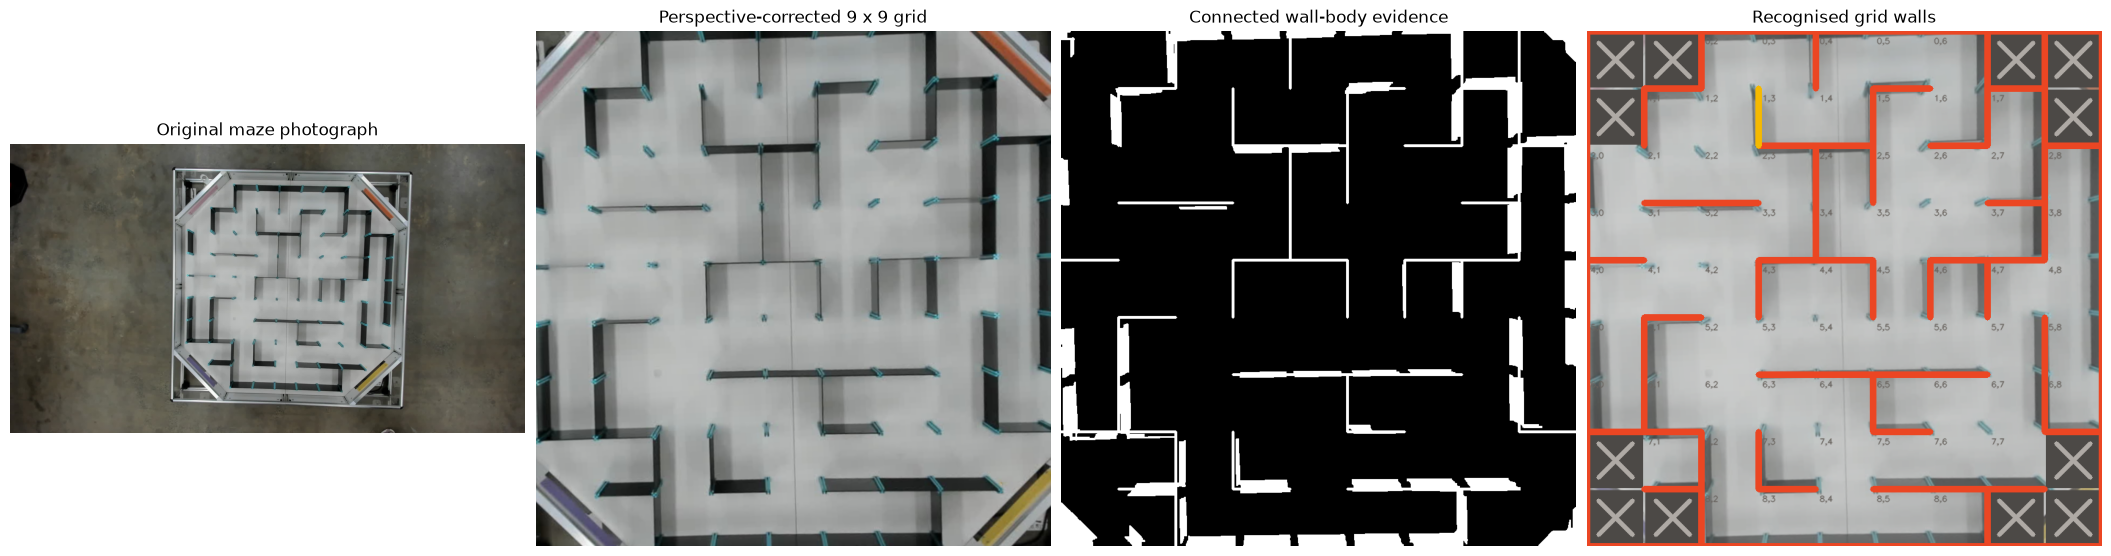

Wall confidence threshold: 0.850
Automatically blocked cells: 12
Maze recognition complete. Run the next cell to choose start and goal poses.


In [6]:
import matplotlib.pyplot as plt

original_image = read_image(IMAGE_FILE)
rectified_image, _ = rectify_maze(original_image, ROWS, COLUMNS)
maze, occupancy_image = extract_maze(rectified_image, ROWS, COLUMNS)

preview = NavigatorUI(
    IMAGE_FILE,
    original_image,
    rectified_image,
    occupancy_image,
    maze,
    OUTPUT_DIRECTORY,
    None,
)
detected_layout = preview.render()
maze_width = COLUMNS * DISPLAY_CELL_PX

fig, axes = plt.subplots(1, 4, figsize=(21, 6), constrained_layout=True)
axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original maze photograph")
axes[1].imshow(cv2.cvtColor(rectified_image, cv2.COLOR_BGR2RGB))
axes[1].set_title("Perspective-corrected 9 x 9 grid")
axes[2].imshow(occupancy_image, cmap="gray")
axes[2].set_title("Connected wall-body evidence")
axes[3].imshow(cv2.cvtColor(detected_layout[:, :maze_width], cv2.COLOR_BGR2RGB))
axes[3].set_title("Recognised grid walls")
for axis in axes:
    axis.axis("off")
plt.show()

print(f"Wall confidence threshold: {maze.threshold:.3f}")
print(f"Automatically blocked cells: {int(np.count_nonzero(maze.blocked_cells))}")
print("Maze recognition complete. Run the next cell to choose start and goal poses.")


## 7. Select start, goal and headings

Running this cell opens the original photograph and the recognised maze in separate windows.

- Drag inside a cell in the desired heading to set the **start pose**.
- Drag inside another cell to set the **goal pose and required final heading**.
- A short click followed by `N`, `E`, `S`, or `W` is an alternative.
- `R` or right-click resets; `S` saves; `Q` or `Esc` closes the windows.

The blue line is the route. The generated command string is printed below and saved in `output/commands.txt`.


In [ ]:
try:
    import tkinter as tk

    clipboard_root = tk.Tk()
    clipboard_root.withdraw()
except Exception:
    clipboard_root = None

navigator = NavigatorUI(
    IMAGE_FILE,
    original_image,
    rectified_image,
    occupancy_image,
    maze,
    OUTPUT_DIRECTORY,
    clipboard_root,
)
navigator.run()

if navigator.start is not None and navigator.goal is not None:
    print(f"Start:    {pose_text(navigator.start)}")
    print(f"Goal:     {pose_text(navigator.goal)}")
    print(f"Commands: {navigator.commands}")
    print(f"Saved to: {OUTPUT_DIRECTORY / 'commands.txt'}")
else:
    print("No complete start/goal selection was made.")

if clipboard_root is not None:
    clipboard_root.destroy()


Start: (1,7,S)
Goal:  (8,2,N)
Commands: frfflfffrffflfffll
